In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully!")

All libraries imported successfully!


In [24]:
df = pd.read_csv("student_dropout_dataset_v3.csv")

In [25]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (10000, 19)


In [5]:
df.head()


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [7]:
df.describe()


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [8]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [9]:
df = df.dropna()
print(f"Dataset shape after dropping null values: {df.shape}")


Dataset shape after dropping null values: (9020, 19)


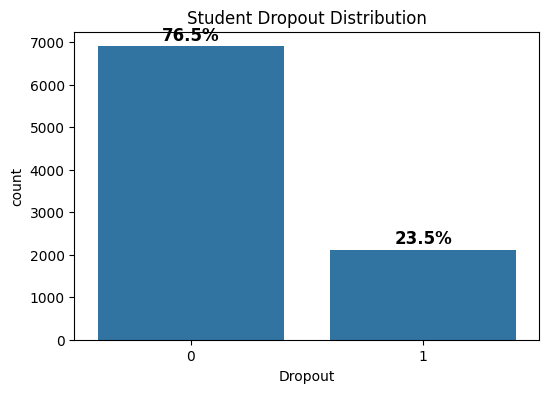

Dropout Rate: 23.48%


In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="Dropout", data=df)
plt.title("Student Dropout Distribution")
dropout_counts = df['Dropout'].value_counts()
total = len(df)
for i, count in enumerate(dropout_counts):
    percentage = (count/total)*100
    plt.text(i, count + 50, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()
print(f"Dropout Rate: {(df['Dropout'].sum()/len(df))*100:.2f}%")

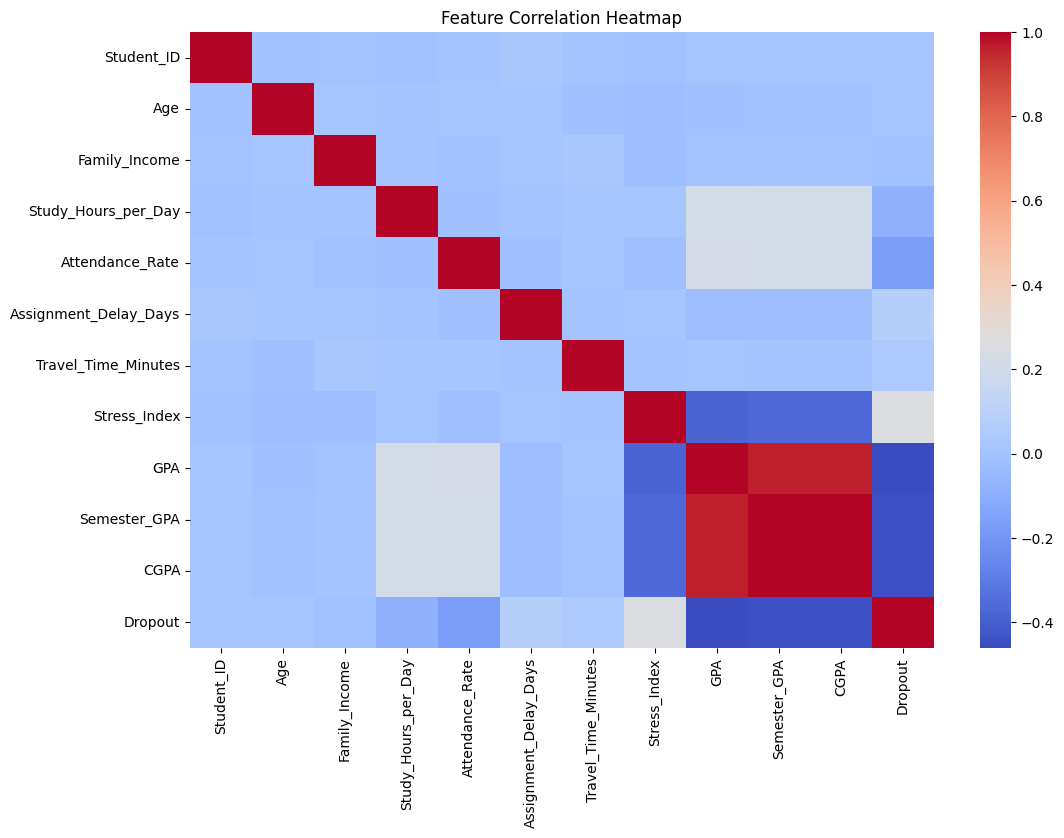

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [12]:
correlation_with_target = df.corr(numeric_only=True)['Dropout'].sort_values(ascending=False)
print("Correlation with Dropout (Target):")
print(correlation_with_target)

Correlation with Dropout (Target):
Dropout                  1.000000
Stress_Index             0.256489
Assignment_Delay_Days    0.076948
Travel_Time_Minutes      0.036298
Age                      0.010582
Student_ID               0.009369
Family_Income           -0.010070
Study_Hours_per_Day     -0.087918
Attendance_Rate         -0.172975
CGPA                    -0.447683
Semester_GPA            -0.448178
GPA                     -0.461352
Name: Dropout, dtype: float64


In [13]:
encoder = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
  df[col] = encoder.fit_transform(df[col])
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,0,0,1,0
1,2,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,2,3,0,1
2,3,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,0,0,2,0
4,5,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,3,1,0,0
6,7,24.5,1,25000.0,1,3.00,78.2,1,37.4,1,1,7.3,0.64,0.33,0.44,3,2,0,0


In [14]:
X = df.drop(["Dropout", "Student_ID"], axis=1)
y = df["Dropout"]
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (9020, 17)
Target shape: (9020,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training Dropout rate: {y_train.mean():.2%}")
print(f"Test Dropout rate: {y_test.mean():.2%}")


Training set size: 7216
Test set size: 1804
Training Dropout rate: 23.48%
Test Dropout rate: 23.50%


In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data scaled successfully!")

Data scaled successfully!


## Model Training & Fine-Tuning

### Fine-Tuning Strategy:
1. **Hyperparameter Optimization**: Using GridSearchCV to find optimal parameters
2. **Class Imbalance Handling**: Using `class_weight='balanced'` for Random Forest
3. **Cross-Validation**: 5-fold CV to ensure model generalizes well
4. **Feature Selection**: Dropping Student_ID to reduce noise
"""

In [17]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression trained")

Logistic Regression trained


In [21]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree trained")

Decision Tree trained


In [26]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
print("Starting RandomizedSearchCV for Random Forest...")
grid_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,              # Only 20 random combinations
    cv=3,                   # 3-fold CV (faster)
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
grid_search.fit(X_train, y_train)
rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
rf_pred = rf.predict(X_test)

Starting RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30}
Best CV Score: 0.7148


In [27]:
# Define evaluation function
def evaluate_model(name, y_true, y_pred, y_proba=None):
    # Create dictionary with metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

    # If probability scores provided, add ROC-AUC
    if y_proba is not None:
        # roc_auc_score: Area under ROC curve
        # Measures model's ability to separate classes
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)

    return metrics

# Initialize empty list for results
results = []

# Get prediction probabilities for Logistic Regression
# .predict_proba(): Returns probabilities for each class
# [:, 1]: Select probability of class 1 (Dropout)
lr_proba = lr.predict_proba(X_test)[:, 1]
results.append(evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba))

# Get prediction probabilities for Decision Tree
dt_proba = dt.predict_proba(X_test)[:, 1]
results.append(evaluate_model("Decision Tree", y_test, dt_pred, dt_proba))

# Get prediction probabilities for Random Forest (Tuned)
rf_proba = rf.predict_proba(X_test)[:, 1]
results.append(evaluate_model("Random Forest (Tuned)", y_test, rf_pred, rf_proba))

# Convert results to DataFrame for display
results_df = pd.DataFrame(results)

# Display the results
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.741131,0.468521,0.754717,0.578139,0.816593
1,Decision Tree,0.730044,0.446520,0.620283,0.519250,0.698369
2,Random Forest (Tuned),0.784922,0.543062,0.535377,0.539192,0.799641


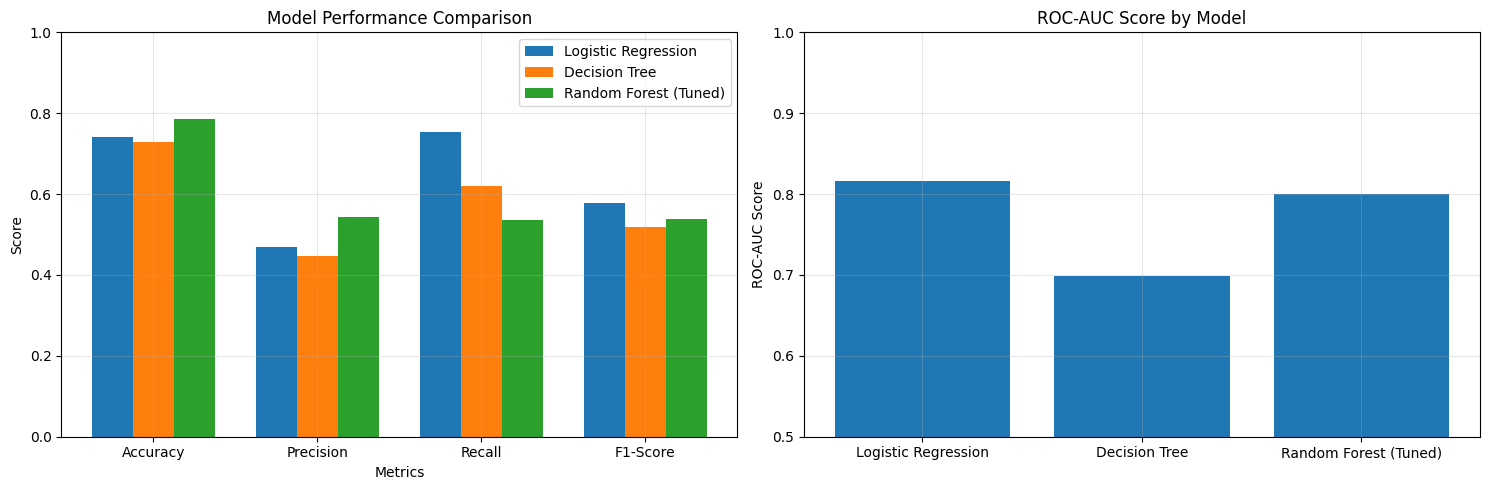

In [28]:
# Create subplots (1 row, 2 columns) with figure size 15x5
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# List of metrics to plot
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create x-axis positions
x = np.arange(len(metrics_to_plot))

# Width of each bar
width = 0.25

# Loop through each model
for i, model in enumerate(results_df['Model']):
    # Get metric values for this model
    values = results_df.loc[i, metrics_to_plot].values
    # Create bars at correct positions
    axes[0].bar(x + i*width, values, width, label=model)

# Configure first subplot
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width)  # Center x-ticks
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].set_ylim(0, 1)  # Set y-axis from 0 to 1
axes[0].grid(True, alpha=0.3)  # Add grid with 30% opacity

# Plot ROC-AUC scores if available
if 'ROC-AUC' in results_df.columns:
    axes[1].bar(results_df['Model'], results_df['ROC-AUC'])
    axes[1].set_title('ROC-AUC Score by Model')
    axes[1].set_ylabel('ROC-AUC Score')
    axes[1].set_ylim(0.5, 1)  # ROC-AUC ranges from 0.5 to 1
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()  # Prevents overlapping elements
plt.show()


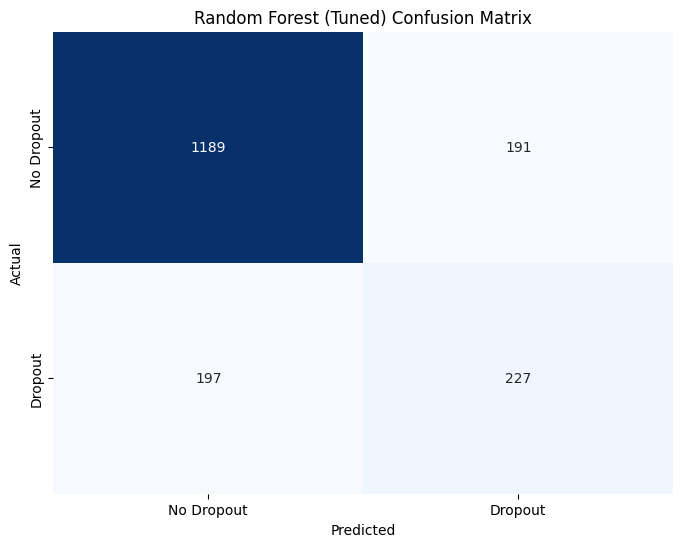

True Negatives: 1189
False Positives: 191
False Negatives: 197
True Positives: 227

Sensitivity (Recall): 0.5354
Specificity: 0.8616
Precision: 0.5431


In [29]:
# .confusion_matrix(): Create confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Create figure
plt.figure(figsize=(8, 6))

# .heatmap(): Create heatmap of confusion matrix
# annot=True: Show numbers in cells
# fmt="d": Display integers
# cbar=False: Hide color bar
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=['No Dropout', 'Dropout'],
    yticklabels=['No Dropout', 'Dropout']
)

plt.title("Random Forest (Tuned) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Extract values from confusion matrix
# ravel(): Flattens 2x2 matrix into 4 values
tn, fp, fn, tp = cm.ravel()

# Display confusion matrix values
print(f"True Negatives: {tn}")   # Correctly predicted No Dropout
print(f"False Positives: {fp}")  # Incorrectly predicted Dropout (Type I error)
print(f"False Negatives: {fn}")  # Missed Dropout (Type II error)
print(f"True Positives: {tp}")   # Correctly predicted Dropout

# Calculate additional metrics
print(f"\nSensitivity (Recall): {tp/(tp+fn):.4f}")  # True positive rate
print(f"Specificity: {tn/(tn+fp):.4f}")            # True negative rate
print(f"Precision: {tp/(tp+fp):.4f}")              # Positive predictive value

In [30]:
# Create DataFrame with feature names and their importance scores
importance = pd.DataFrame({
    "Feature": X.columns,                           # Feature names
    "Importance": rf.feature_importances_           # Importance values
})

# Sort by Importance descending (most important first)
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Display sorted features
importance

,Feature,Importance
11,GPA,0.202609
13,CGPA,0.156897
12,Semester_GPA,0.150744
10,Stress_Index,0.082890
5,Attendance_Rate,0.075163
4,Study_Hours_per_Day,0.061375
7,Travel_Time_Minutes,0.058587
0,Age,0.052664
2,Family_Income,0.042053
6,Assignment_Delay_Days,0.027931


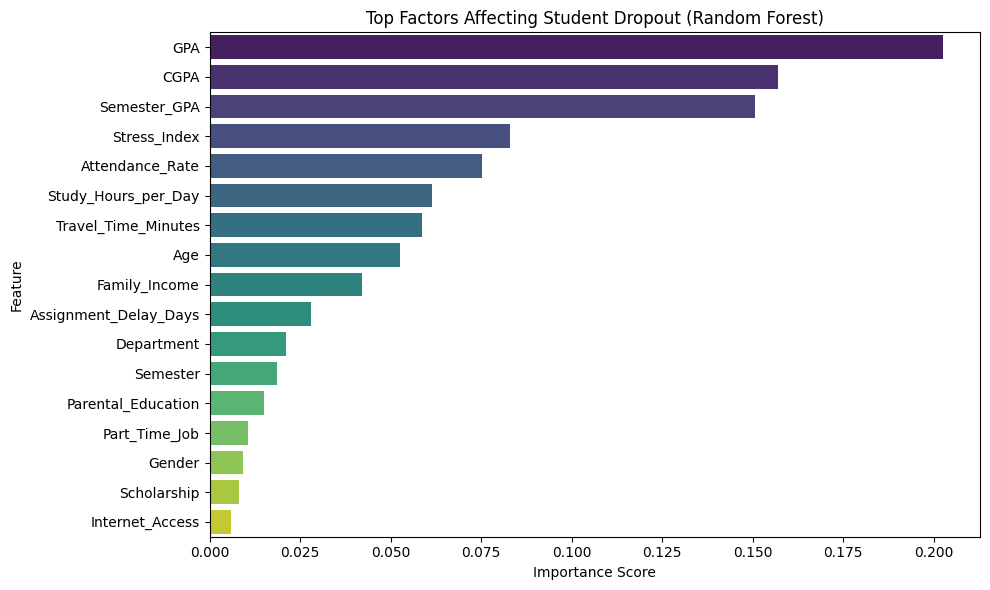

In [31]:
# Create figure
plt.figure(figsize=(10, 6))

# Create horizontal bar plot
# x="Importance": Values for x-axis
# y="Feature": Categories for y-axis
# palette="viridis": Color scheme
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top Factors Affecting Student Dropout (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [32]:
# cross_val_score(): Evaluate model using cross-validation
# cv=5: 5-fold cross-validation
# scoring='accuracy': Use accuracy as evaluation metric
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)

# Calculate mean and confidence interval
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Also evaluate F1 score with cross-validation
cv_f1 = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_macro')
print(f"Mean CV F1-Score: {cv_f1.mean():.4f}")

Cross-Validation Scores: [0.81578947 0.79140679 0.7997228  0.78724879 0.79279279]
Mean CV Accuracy: 0.7974 (+/- 0.0201)
Mean CV F1-Score: 0.7132


In [33]:
# Take first student from the dataset as sample
# .iloc[[0]]: Select first row as DataFrame (keeps 2D structure)
sample = X.iloc[[0]]

# Scale the sample using the same scaler
sample_scaled = scaler.transform(sample)

# .predict(): Get class prediction (0 or 1)
prediction = rf.predict(sample_scaled)

# .predict_proba(): Get probability scores
# [0][1]: Get probability of class 1 (Dropout)
probability = rf.predict_proba(sample_scaled)[0][1]

# Check prediction and display appropriate message
if prediction[0] == 1:
    print(f"⚠️ Student is at Dropout Risk (Confidence: {probability:.2%})")
else:
    print(f"✅ Student is Safe (Confidence: {1-probability:.2%})")

✅ Student is Safe (Confidence: 52.81%)
